# Practical Session: Surface Energy Balance (SEB) & Eddy Covariance Processing

## 1. Introduction and Objectives
This notebook integrates micrometeorological observations from a surface radiation station and Eddy Covariance (EddyPro) atmospheric flux outputs. 

### Key Objectives:
1. **Time Synchronization**: Align observation timestamps by applying UTC offset adjustments ($+3\text{ hours}$).
2. **Data Regularization**: Resample multi-rate fluxes into regular $1\text{-hour}$ averages.
3. **Radiation Correction**: Correct unphysical night-time shortwave radiation readings ($S_{\uparrow}, S_{\downarrow} < 0$).
4. **Surface Energy Balance (SEB) Evaluation**:
   - Calculate Net Radiation ($R_n$):
     $$R_n = (S_{\downarrow} - S_{\uparrow}) + (L_{\downarrow} - L_{\uparrow})$$
   - Quantify total energy consumption ($H + LE + G$).
   - Compute the surface energy imbalance residual ($R_n - (H + LE + G)$).
5. **Quality Control & Outlier Filtering**: Compare raw SEB closure against outlier-filtered turbulent fluxes.

---

## 2. Environment Setup
Import required standard numerical analysis, file I/O, and data visualization libraries.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 3. Data Ingestion & Time-Zone Adjustment
Load radiation and soil observations from the meteorological tower, adjust UTC timestamps by $+3\text{ hours}$, and set a unified `DatetimeIndex`.

In [2]:
# File path to hourly meteorological tower observations
filename = "data/pross/met_data_1h.csv"

# Load data and adjust local time offset (+3 hours)
df_tower = pd.read_csv(filename)
df_tower["datetime"] = pd.to_datetime(df_tower["datetime"]) + pd.Timedelta(hours=3)
df_tower = df_tower.set_index("datetime")

df_tower

,SUp,SDn,LUpCo,LDnCo,tair,rh,press,ws,wd,SHF
datetime,,,,,,,,,,
2024-12-05 03:00:00,-1.621271,-0.645508,278.950847,-308.547458,-0.765254,76.260000,1009.343220,0.0,0.705288,-8.388136
2024-12-05 04:00:00,-2.890317,-0.873267,249.340000,-305.000000,-1.202200,77.911333,1009.343383,0.0,0.667983,-7.664483
2024-12-05 05:00:00,-1.856967,-1.455250,239.385000,-302.746667,-1.549267,78.135333,1009.448533,0.0,0.632567,-6.404567
2024-12-05 06:00:00,7.741833,-2.950833,254.713333,-303.516667,-1.609117,77.461833,1009.647250,0.0,0.601150,-5.897800
2024-12-05 07:00:00,73.923833,-20.231583,252.225000,-308.655000,-1.122300,76.896667,1009.670067,0.0,0.648150,-5.436317
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,4.417467,84.013333,989.174752,0.0,1.244800,2.966233
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,3.840650,84.666667,989.347370,0.0,1.213183,0.466983
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,3.494267,84.748333,989.682275,0.0,1.143917,-1.678683


## 4. Processing Eddy Covariance (EddyPro) Outputs
Parse high-frequency flux calculation outputs, handle missing value codes (`-9999`), align time indexes, and resample parameters to $1\text{-hour}$ temporal resolution.

In [3]:
# File path to EddyPro full output
file_path = "data/AP/eddypro_PG_OP43_full_output_2026-10-07T104038_exp.csv"

# Load output while skipping header metadata and replacing missing indicators
df = pd.read_csv(file_path, sep=",", skiprows=[0, 2], na_values=-9999)

# Select micrometeorological and state variables
cols_eddy = ["date", "time", "H", "LE", "air_temperature", "air_pressure", "RH", "wind_speed", "wind_dir"]
df_sel = df[cols_eddy].copy()

# Construct datetime index with time shift (+3 hours)
df_sel["datetime"] = pd.to_datetime(df_sel["date"] + " " + df_sel["time"]) + pd.Timedelta(hours=3)
df_sel = df_sel.set_index("datetime").drop(columns=["date", "time"])

# Restrict study period and resample to 1-hour averages
df_sel = df_sel.loc["2024-12-06":"2024-12-13"].resample("1h").mean()
df_sel

,H,LE,air_temperature,air_pressure,RH,wind_speed,wind_dir
datetime,,,,,,,
2024-12-06 00:00:00,-1.908835,11.726675,271.9120,101644.00,31.62395,5.561705,42.87180
2024-12-06 01:00:00,0.633950,7.187745,271.7135,101676.50,32.08870,4.203325,56.63085
2024-12-06 02:00:00,-2.276530,7.318595,271.7515,101694.00,31.39660,3.549855,65.84880
2024-12-06 03:00:00,-2.792265,11.428400,271.8340,101680.50,29.41310,5.124625,62.91175
2024-12-06 04:00:00,0.288141,2.755180,271.8150,101691.00,33.93900,4.898640,75.59880
...,...,...,...,...,...,...,...
2024-12-12 23:00:00,-0.408915,1.168020,277.5425,99309.15,77.53695,2.593265,136.68550
2024-12-13 00:00:00,0.993453,2.806195,277.3145,99294.50,79.16630,1.406416,156.92650
2024-12-13 01:00:00,6.958615,5.851220,276.7860,99316.50,78.05580,1.661170,191.87000


## 5. Dataset Integration & Shortwave Radiation Correction
Merge tower radiation and flux observations on common timestamps. Clean unphysical night-time shortwave radiation readings where sensors measure negative values.

In [4]:
# Select target parameters from each source
cols_tower = ["SUp", "SDn", "LUpCo", "LDnCo", "SHF"]
cols_turbulent = ["H", "LE"]

# Merge tower observations with turbulent flux observations
df_merged = pd.merge(df_tower[cols_tower], df_sel[cols_turbulent], on="datetime", how="inner")

# Zero-out night-time shortwave radiation artifacts (SUp < 0)
df_merged.loc[df_merged['SUp'] < 0, ['SUp', 'SDn']] = 0

df_merged

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE
datetime,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.908835,11.726675
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.633950,7.187745
2024-12-06 02:00:00,0.000000,0.000000,212.940000,-300.505000,-8.456500,-2.276530,7.318595
2024-12-06 03:00:00,0.000000,0.000000,214.573333,-300.468333,-8.127267,-2.792265,11.428400
2024-12-06 04:00:00,0.000000,0.000000,215.496667,-300.398333,-7.540617,0.288141,2.755180
...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.408915,1.168020
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,0.993453,2.806195
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,6.958615,5.851220


## 6. Raw Surface Energy Balance (SEB) Calculation
Compute Net Radiation ($R_n$), Total Consumed Heat ($H + LE + G$), and Residual Imbalance prior to filtering flux spikes.

In [5]:
# Compute Net Radiation (Rn) and Energy Balance components
df_merged["Rn"] = (df_merged["SDn"] + df_merged["SUp"]) + (df_merged["LDnCo"] + df_merged["LUpCo"])
df_merged["SEB_Consumed"] = df_merged["H"] + df_merged["LE"] + df_merged["SHF"]
df_merged["SEB_Residual"] = df_merged["Rn"] - df_merged["SEB_Consumed"]

df_merged

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE,Rn,SEB_Consumed,SEB_Residual
datetime,,,,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.908835,11.726675,-67.169783,3.027523,-70.197307
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.633950,7.187745,-85.032683,-0.516305,-84.516378
2024-12-06 02:00:00,0.000000,0.000000,212.940000,-300.505000,-8.456500,-2.276530,7.318595,-87.565000,-3.414435,-84.150565
2024-12-06 03:00:00,0.000000,0.000000,214.573333,-300.468333,-8.127267,-2.792265,11.428400,-85.895000,0.508868,-86.403868
2024-12-06 04:00:00,0.000000,0.000000,215.496667,-300.398333,-7.540617,0.288141,2.755180,-84.901667,-4.497296,-80.404371
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.408915,1.168020,7.420533,3.725338,3.695195
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,0.993453,2.806195,-1.073317,4.266632,-5.339948
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,6.958615,5.851220,-10.824550,11.131152,-21.955702


### Plot 1: Unfiltered Surface Energy Balance (SEB)
Visualization showing radiation fluxes, turbulent and soil heat fluxes, and energy balance closure using raw, unfiltered EddyPro measurements.

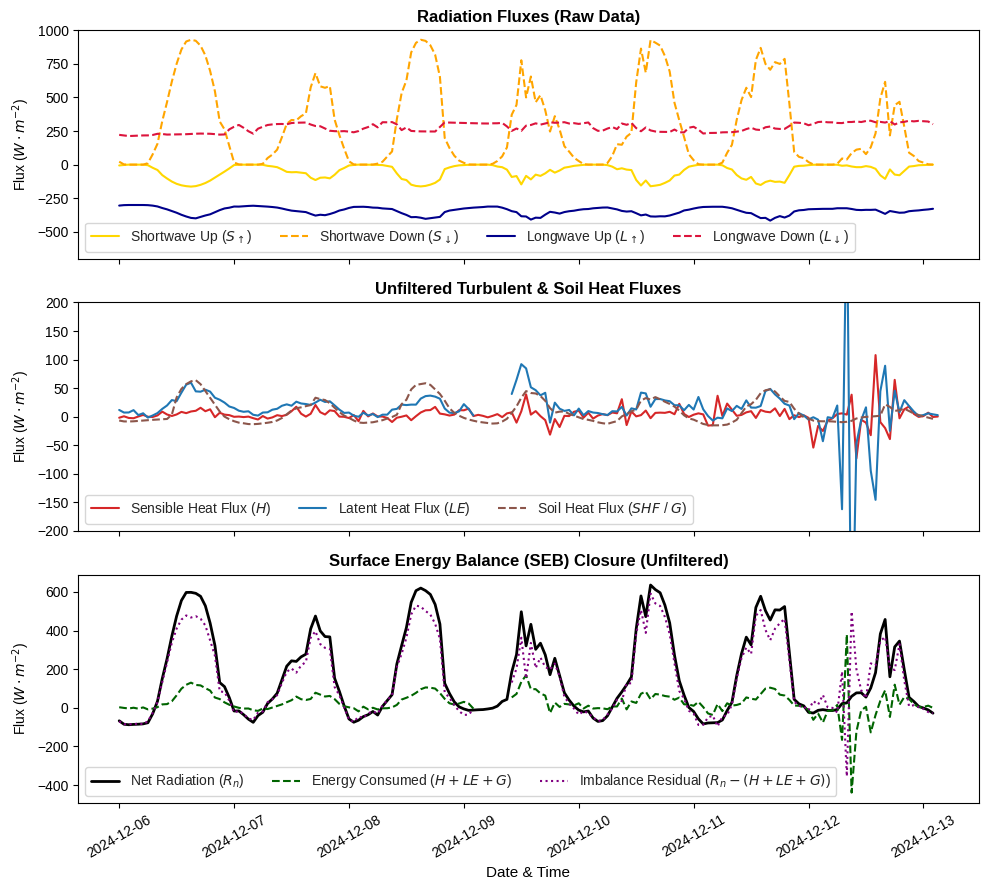

In [6]:
# Figure setup for unfiltered SEB components
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# --- Subplot 1: Radiation Components ---
ax1.plot(df_merged.index, df_merged["SDn"], label="Shortwave Up ($S_{\\uparrow}$)", color="gold", linewidth=1.5)
ax1.plot(df_merged.index, df_merged["SUp"], label="Shortwave Down ($S_{\\downarrow}$)", color="orange", linestyle="--", linewidth=1.5)
ax1.plot(df_merged.index, df_merged["LDnCo"], label="Longwave Up ($L_{\\uparrow}$)", color="darkblue", linewidth=1.5)
ax1.plot(df_merged.index, df_merged["LUpCo"], label="Longwave Down ($L_{\\downarrow}$)", color="crimson", linestyle="--", linewidth=1.5)
ax1.set_ylabel("Flux ($W \cdot m^{-2}$)", fontsize=10)
ax1.set_title("Radiation Fluxes (Raw Data)", fontsize=12, fontweight="bold")
ax1.set_ylim(-700, 1000)
ax1.legend(loc="lower left", frameon=True, ncol=4)

# --- Subplot 2: Unfiltered Turbulent & Soil Heat Fluxes ---
ax2.plot(df_merged.index, df_merged["H"], label="Sensible Heat Flux ($H$)", color="tab:red", linewidth=1.5)
ax2.plot(df_merged.index, df_merged["LE"], label="Latent Heat Flux ($LE$)", color="tab:blue", linewidth=1.5)
ax2.plot(df_merged.index, df_merged["SHF"], label="Soil Heat Flux ($SHF$ / $G$)", color="tab:brown", linestyle="--", linewidth=1.5)
ax2.set_ylabel("Flux ($W \cdot m^{-2}$)", fontsize=10)
ax2.set_ylim(-200, 200)
ax2.set_title("Unfiltered Turbulent & Soil Heat Fluxes", fontsize=12, fontweight="bold")
ax2.legend(loc="lower left", frameon=True, ncol=3)

# --- Subplot 3: Unfiltered Surface Energy Balance ---
ax3.plot(df_merged.index, df_merged["Rn"], label="Net Radiation ($R_n$)", color="black", linewidth=2)
ax3.plot(df_merged.index, df_merged["SEB_Consumed"], label="Energy Consumed ($H + LE + G$)", color="darkgreen", linestyle="--", linewidth=1.5)
ax3.plot(df_merged.index, df_merged["SEB_Residual"], label="Imbalance Residual ($R_n - (H+LE+G)$)", color="purple", linestyle=":", linewidth=1.5)
ax3.set_ylabel("Flux ($W \cdot m^{-2}$)", fontsize=10)
ax3.set_xlabel("Date & Time", fontsize=11)
ax3.set_title("Surface Energy Balance (SEB) Closure (Unfiltered)", fontsize=12, fontweight="bold")
ax3.legend(loc="lower left", frameon=True, ncol=3)

plt.xticks(rotation=30)
plt.tight_layout()

# Save figure
os.makedirs("fig", exist_ok=True)
plt.savefig("fig/fig_seb_raw.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Turbulent Flux Quality Control & Outlier Filtering
Filter out spurious turbulent flux spikes exceeding realistic thresholds and linearly interpolate missing gaps across time.

In [7]:
# Quality control filtering threshold (|Flux| > 150 W/m2)
cols_turbulent = ['H', 'LE']
df_merged[cols_turbulent] = df_merged[cols_turbulent].mask(
    (df_merged[cols_turbulent] < -150) | (df_merged[cols_turbulent] > 150)
)

# Time-based interpolation of gap values
df_merged[cols_turbulent] = df_merged[cols_turbulent].interpolate(method='time')

# Recompute energy balance terms with filtered fluxes
df_merged["SEB_Consumed"] = df_merged["H"] + df_merged["LE"] + df_merged["SHF"]
df_merged["SEB_Residual"] = df_merged["Rn"] - df_merged["SEB_Consumed"]

df_merged

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE,Rn,SEB_Consumed,SEB_Residual
datetime,,,,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.908835,11.726675,-67.169783,3.027523,-70.197307
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.633950,7.187745,-85.032683,-0.516305,-84.516378
2024-12-06 02:00:00,0.000000,0.000000,212.940000,-300.505000,-8.456500,-2.276530,7.318595,-87.565000,-3.414435,-84.150565
2024-12-06 03:00:00,0.000000,0.000000,214.573333,-300.468333,-8.127267,-2.792265,11.428400,-85.895000,0.508868,-86.403868
2024-12-06 04:00:00,0.000000,0.000000,215.496667,-300.398333,-7.540617,0.288141,2.755180,-84.901667,-4.497296,-80.404371
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.408915,1.168020,7.420533,3.725338,3.695195
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,0.993453,2.806195,-1.073317,4.266632,-5.339948
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,6.958615,5.851220,-10.824550,11.131152,-21.955702


### Plot 2: Quality-Controlled Surface Energy Balance (SEB)
Visualization showing radiation, turbulent, and soil fluxes after removing unrealistic spikes.

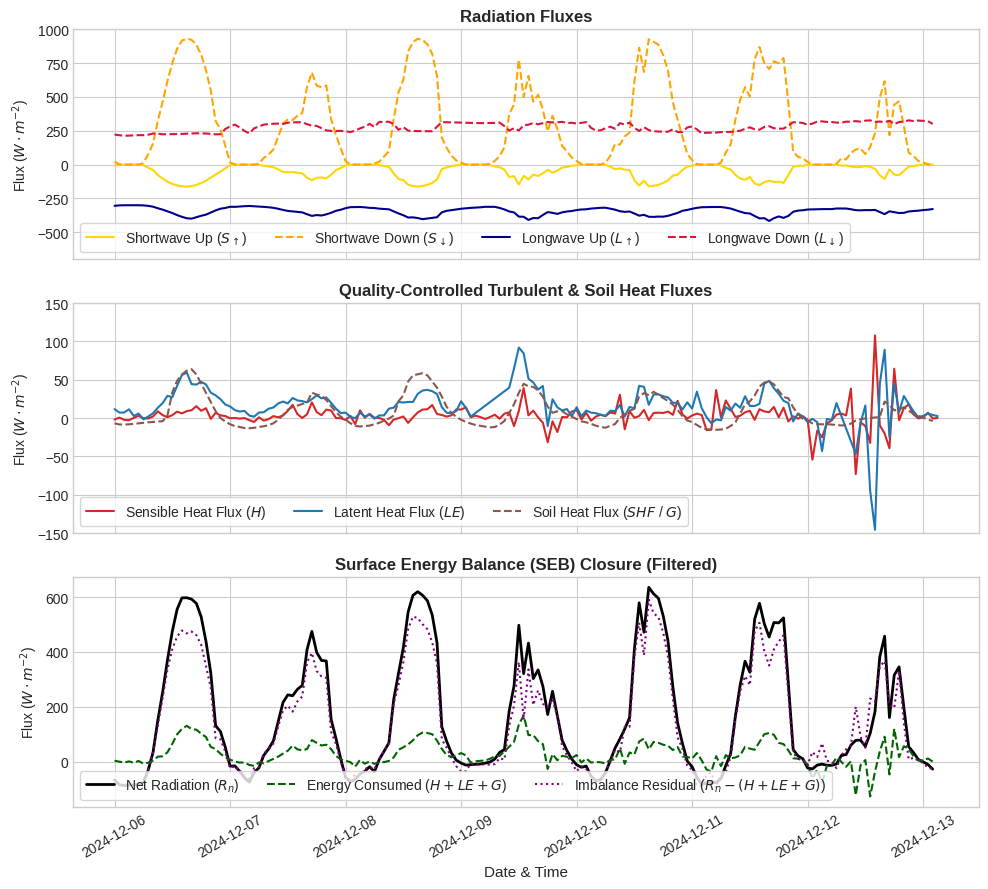

In [8]:
# Figure setup for quality-controlled SEB components
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# --- Subplot 1: Radiation Fluxes ---
ax1.plot(df_merged.index, df_merged["SDn"], label="Shortwave Up ($S_{\\uparrow}$)", color="gold", linewidth=1.5)
ax1.plot(df_merged.index, df_merged["SUp"], label="Shortwave Down ($S_{\\downarrow}$)", color="orange", linestyle="--", linewidth=1.5)
ax1.plot(df_merged.index, df_merged["LDnCo"], label="Longwave Up ($L_{\\uparrow}$)", color="darkblue", linewidth=1.5)
ax1.plot(df_merged.index, df_merged["LUpCo"], label="Longwave Down ($L_{\\downarrow}$)", color="crimson", linestyle="--", linewidth=1.5)
ax1.set_ylabel("Flux ($W \cdot m^{-2}$)", fontsize=10)
ax1.set_title("Radiation Fluxes", fontsize=12, fontweight="bold")
ax1.set_ylim(-700, 1000)
ax1.legend(loc="lower left", frameon=True, ncol=4)

# --- Subplot 2: Quality-Controlled Turbulent & Soil Fluxes ---
ax2.plot(df_merged.index, df_merged["H"], label="Sensible Heat Flux ($H$)", color="tab:red", linewidth=1.5)
ax2.plot(df_merged.index, df_merged["LE"], label="Latent Heat Flux ($LE$)", color="tab:blue", linewidth=1.5)
ax2.plot(df_merged.index, df_merged["SHF"], label="Soil Heat Flux ($SHF$ / $G$)", color="tab:brown", linestyle="--", linewidth=1.5)
ax2.set_ylabel("Flux ($W \cdot m^{-2}$)", fontsize=10)
ax2.set_ylim(-150, 150)
ax2.set_title("Quality-Controlled Turbulent & Soil Heat Fluxes", fontsize=12, fontweight="bold")
ax2.legend(loc="lower left", frameon=True, ncol=3)

# --- Subplot 3: Quality-Controlled Surface Energy Balance ---
ax3.plot(df_merged.index, df_merged["Rn"], label="Net Radiation ($R_n$)", color="black", linewidth=2)
ax3.plot(df_merged.index, df_merged["SEB_Consumed"], label="Energy Consumed ($H + LE + G$)", color="darkgreen", linestyle="--", linewidth=1.5)
ax3.plot(df_merged.index, df_merged["SEB_Residual"], label="Imbalance Residual ($R_n - (H+LE+G)$)", color="purple", linestyle=":", linewidth=1.5)
ax3.set_ylabel("Flux ($W \cdot m^{-2}$)", fontsize=10)
ax3.set_xlabel("Date & Time", fontsize=11)
ax3.set_title("Surface Energy Balance (SEB) Closure (Filtered)", fontsize=12, fontweight="bold")
ax3.legend(loc="lower left", frameon=True, ncol=3)

plt.xticks(rotation=30)
plt.tight_layout()

# Save figure
plt.savefig("fig/fig_seb_corr.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Export Processed Micrometeorological Dataset
Combine all surface energy balance components with additional atmospheric parameters (`air_temperature`, `air_pressure`, `RH`, `wind_speed`, `wind_dir`) and save to a clean TSV file.

In [9]:
# Concatenate additional atmospheric measurements
df_final = pd.concat([
    df_merged,
    df_sel[['air_temperature', 'air_pressure', 'RH', 'wind_speed', 'wind_dir']]
], axis=1, join="inner")

# Export dataset
output_path = "data/pross/data_tower.csv"
df_final.to_csv(output_path, sep="\t")
df_final

,SUp,SDn,LUpCo,LDnCo,SHF,H,LE,Rn,SEB_Consumed,SEB_Residual,air_temperature,air_pressure,RH,wind_speed,wind_dir
datetime,,,,,,,,,,,,,,,
2024-12-06 00:00:00,22.027583,-6.099033,221.720000,-304.818333,-6.790317,-1.908835,11.726675,-67.169783,3.027523,-70.197307,271.9120,101644.00,31.62395,5.561705,42.87180
2024-12-06 01:00:00,1.502833,-2.493850,217.453333,-301.495000,-8.338000,0.633950,7.187745,-85.032683,-0.516305,-84.516378,271.7135,101676.50,32.08870,4.203325,56.63085
2024-12-06 02:00:00,0.000000,0.000000,212.940000,-300.505000,-8.456500,-2.276530,7.318595,-87.565000,-3.414435,-84.150565,271.7515,101694.00,31.39660,3.549855,65.84880
2024-12-06 03:00:00,0.000000,0.000000,214.573333,-300.468333,-8.127267,-2.792265,11.428400,-85.895000,0.508868,-86.403868,271.8340,101680.50,29.41310,5.124625,62.91175
2024-12-06 04:00:00,0.000000,0.000000,215.496667,-300.398333,-7.540617,0.288141,2.755180,-84.901667,-4.497296,-80.404371,271.8150,101691.00,33.93900,4.898640,75.59880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12 23:00:00,26.785000,-4.576133,325.865000,-340.653333,2.966233,-0.408915,1.168020,7.420533,3.725338,3.695195,277.5425,99309.15,77.53695,2.593265,136.68550
2024-12-13 00:00:00,15.160833,-2.779150,323.041667,-336.496667,0.466983,0.993453,2.806195,-1.073317,4.266632,-5.339948,277.3145,99294.50,79.16630,1.406416,156.92650
2024-12-13 01:00:00,2.367917,-0.795800,320.983333,-333.380000,-1.678683,6.958615,5.851220,-10.824550,11.131152,-21.955702,276.7860,99316.50,78.05580,1.661170,191.87000
